In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("car data.csv")

print(df.head())
print(df.shape)
print(df.info())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301

In [5]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New shape:", df.shape)

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
Duplicates: 2
New shape: (299, 9)


In [6]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [7]:
df = df.drop("Year", axis=1)

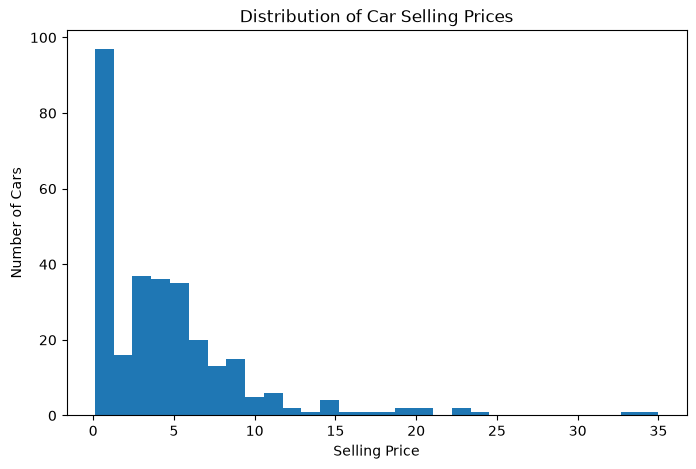

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["Selling_Price"], bins=30)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

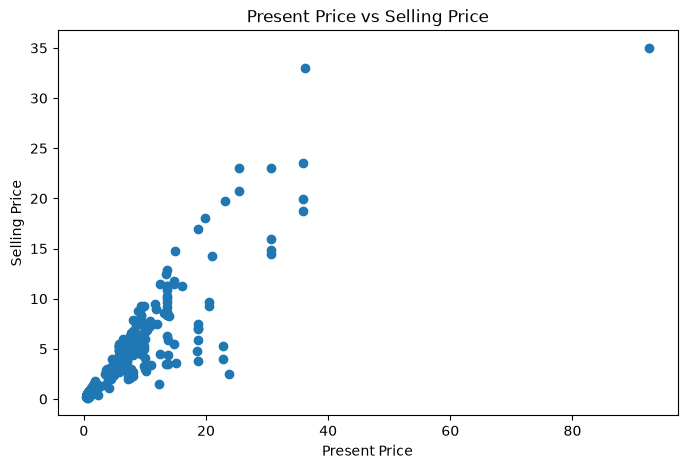

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"]
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

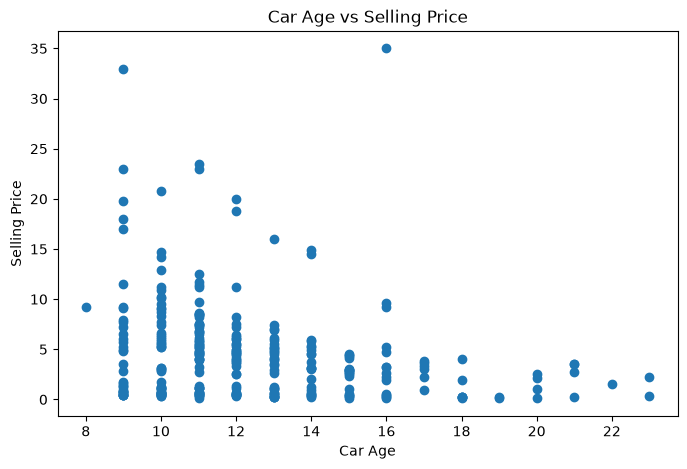

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Car_Age"],
    df["Selling_Price"]
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

In [11]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [12]:
numeric_features = [
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

categorical_features = [
    "Car_Name",
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [15]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [16]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [18]:
def evaluate_model(model_name, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R² Score:", r2)


evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

evaluate_model(
    "Random Forest Regression",
    y_test,
    y_pred_rf
)

evaluate_model(
    "Gradient Boosting Regression",
    y_test,
    y_pred_gb
)


Linear Regression
----------------------------------------
MAE : 1.4121464590558985
MSE : 5.912838007386681
RMSE: 2.4316327862953897
R² Score: 0.7705824758850854

Random Forest Regression
----------------------------------------
MAE : 1.4051116666666665
MSE : 11.572413698166681
RMSE: 3.4018250540212502
R² Score: 0.5509915043587802

Gradient Boosting Regression
----------------------------------------
MAE : 1.1658077667801525
MSE : 7.015637712765408
RMSE: 2.648704912361022
R² Score: 0.7277939574635459


In [19]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

print(comparison.head(10))

   Actual Price  Predicted Price
0          8.99          9.53750
1          8.35          8.00955
2          0.45          0.44095
3          7.45          7.27975
4          5.25         16.80995
5          5.25          5.32775
6          5.85          6.76950
7          1.15          1.19250
8          9.25          7.86205
9          0.38          0.30835


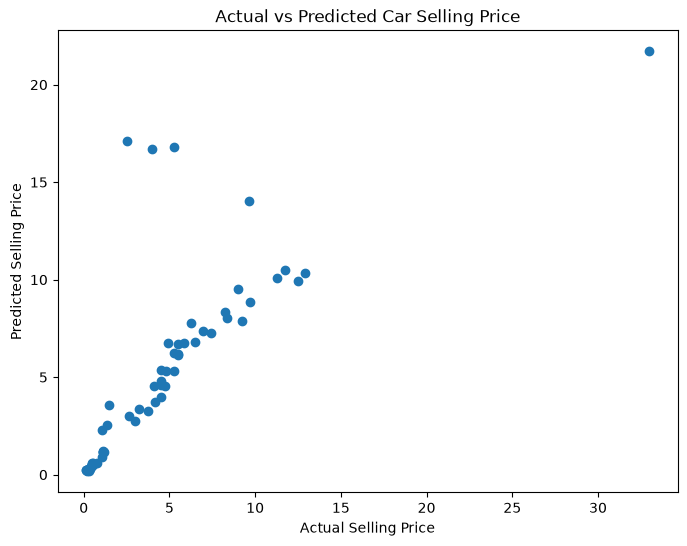

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title(
    "Actual vs Predicted Car Selling Price"
)

plt.show()

In [21]:
new_car = pd.DataFrame({
    "Car_Name": ["ciaz"],
    "Present_Price": [10.0],
    "Driven_kms": [30000],
    "Fuel_Type": ["Petrol"],
    "Selling_type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0],
    "Car_Age": [4]
})

In [22]:
predicted_price = rf_model.predict(new_car)

print(
    "Predicted Car Selling Price:",
    predicted_price[0]
)

Predicted Car Selling Price: 7.5928
